In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import warnings

In [ ]:
# --- Global Configurations ---
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# -----------------------------------------------------------------------------
# STEP 1: LOAD & CLEAN DATA
# -----------------------------------------------------------------------------
#from google.colab import files
#uploaded = files.upload()

# Load the Air Quality UCI dataset
df = pd.read_csv('AirQualityUCI.csv')

# The dataset uses -200 to represent missing values
df.replace(-200, np.nan, inplace=True)

# Fill missing numerical values using interpolation
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].interpolate(method='linear')

# Handle any remaining NaN values at start/end
df[num_cols] = df[num_cols].bfill().ffill()


In [ ]:
df.head()

,Date,Time,CO_GT,PT08_S1_CO,NMHC_GT,C6H6_GT,PT08_S2_NMHC,Nox_GT,PT08_S3_Nox,NO2_GT,PT08_S4_NO2,PT08_S5_O3,T,RH,AH,CO_level
0,11/23/2004,19:00:00,11.9,2008.0,618.0,50.6,1980.0,1389.0,325.0,220.0,2562.0,2342.0,12.4,74.7,1.0741,Very High
1,11/23/2004,20:00:00,11.5,1918.0,618.0,49.4,1958.0,1358.0,335.0,190.0,2477.0,2237.0,11.5,76.2,1.0324,Very High
2,11/17/2004,18:00:00,10.2,1802.0,618.0,47.7,1924.0,748.0,356.0,192.0,2235.0,2452.0,13.7,52.8,0.8244,Very High
3,11/23/2004,18:00:00,10.2,1982.0,618.0,49.5,1959.0,1369.0,322.0,227.0,2536.0,2386.0,13.2,72.6,1.0936,Very High
4,11/26/2004,18:00:00,10.1,1956.0,618.0,45.2,1877.0,1389.0,347.0,255.0,2338.0,2465.0,15.5,62.8,1.0979,Very High


In [ ]:
df.tail()

,Date,Time,CO_GT,PT08_S1_CO,NMHC_GT,C6H6_GT,PT08_S2_NMHC,Nox_GT,PT08_S3_Nox,NO2_GT,PT08_S4_NO2,PT08_S5_O3,T,RH,AH,CO_level
9352,3/23/2005,4:00:00,0.1,993.0,59.0,2.3,604.0,85.0,848.0,65.0,1160.0,762.0,14.5,66.4,1.0919,Very low
9353,3/26/2005,4:00:00,0.1,1122.0,59.0,6.0,811.0,181.0,641.0,92.0,1336.0,1122.0,16.2,71.2,1.3013,Very low
9354,3/29/2005,4:00:00,0.1,883.0,59.0,1.3,530.0,63.0,997.0,46.0,1102.0,617.0,13.7,68.2,1.0611,Very low
9355,04/01/2005,4:00:00,0.1,818.0,59.0,0.8,473.0,47.0,1257.0,41.0,898.0,323.0,13.7,48.8,0.7606,Very low
9356,04/04/2005,4:00:00,0.1,864.0,59.0,0.8,478.0,52.0,1116.0,43.0,958.0,489.0,11.8,56.0,0.7743,Very low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          9357 non-null   object 
 1   Time          9357 non-null   object 
 2   CO_GT         9357 non-null   float64
 3   PT08_S1_CO    9357 non-null   float64
 4   NMHC_GT       9357 non-null   float64
 5   C6H6_GT       9357 non-null   float64
 6   PT08_S2_NMHC  9357 non-null   float64
 7   Nox_GT        9357 non-null   float64
 8   PT08_S3_Nox   9357 non-null   float64
 9   NO2_GT        9357 non-null   float64
 10  PT08_S4_NO2   9357 non-null   float64
 11  PT08_S5_O3    9357 non-null   float64
 12  T             9357 non-null   float64
 13  RH            9357 non-null   float64
 14  AH            9357 non-null   float64
 15  CO_level      9357 non-null   object 
dtypes: float64(13), object(3)
memory usage: 1.1+ MB


In [ ]:
df = df.drop(['Date', 'Time','NMHC_GT','CO_GT'], axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PT08_S1_CO    9357 non-null   float64
 1   C6H6_GT       9357 non-null   float64
 2   PT08_S2_NMHC  9357 non-null   float64
 3   Nox_GT        9357 non-null   float64
 4   PT08_S3_Nox   9357 non-null   float64
 5   NO2_GT        9357 non-null   float64
 6   PT08_S4_NO2   9357 non-null   float64
 7   PT08_S5_O3    9357 non-null   float64
 8   T             9357 non-null   float64
 9   RH            9357 non-null   float64
 10  AH            9357 non-null   float64
 11  CO_level      9357 non-null   object 
dtypes: float64(11), object(1)
memory usage: 877.3+ KB


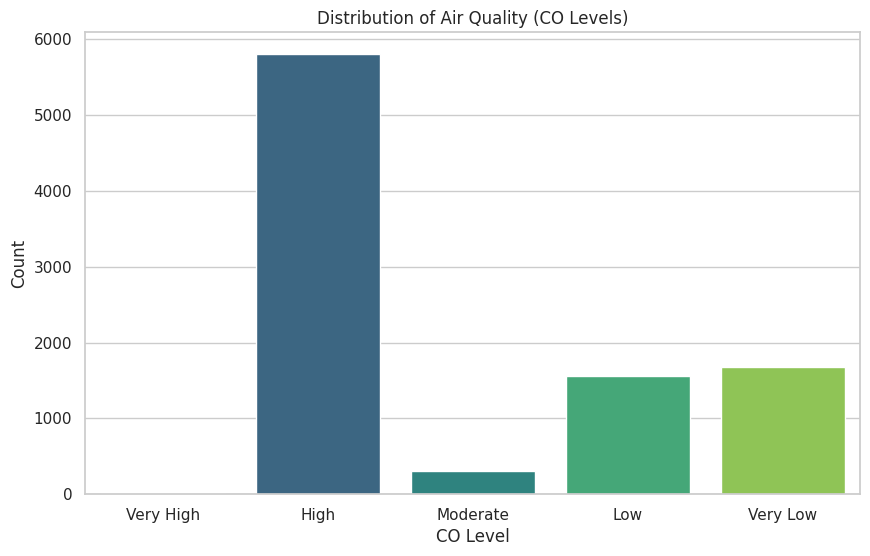

In [ ]:
plt.figure()

# Clean data (important)
df['CO_level'] = df['CO_level'].str.strip().str.title()

# Define correct logical order
order = ['Very High', 'High', 'Moderate', 'Low', 'Very Low']

sns.countplot(
    x='CO_level',
    data=df,
    palette='viridis',
    order=order
)

plt.title('Distribution of Air Quality (CO Levels)')
plt.xlabel('CO Level')
plt.ylabel('Count')

plt.show()

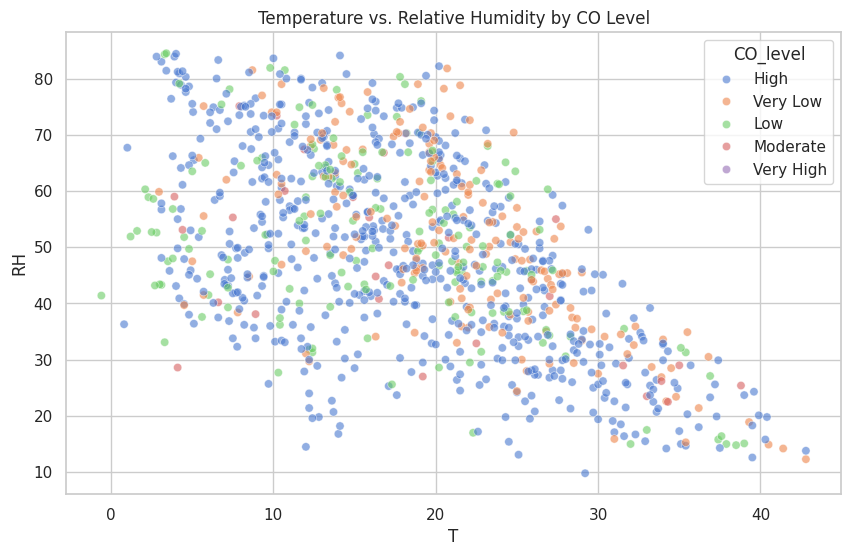

In [ ]:
plt.figure()
sns.scatterplot(x='T', y='RH', hue='CO_level', data=df.sample(1000), alpha=0.6)
plt.title('Temperature vs. Relative Humidity by CO Level')
plt.show()

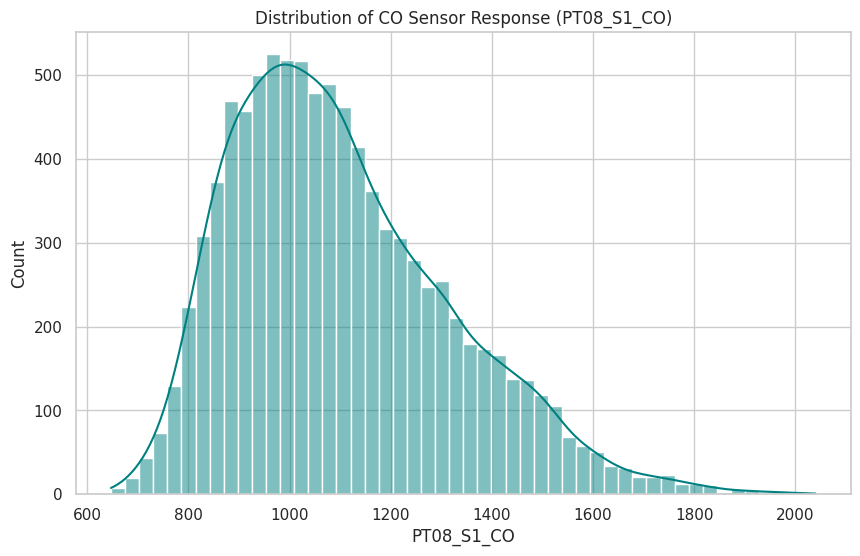

In [ ]:
plt.figure()
sns.histplot(df['PT08_S1_CO'], kde=True, color='teal')
plt.title('Distribution of CO Sensor Response (PT08_S1_CO)')
plt.show()

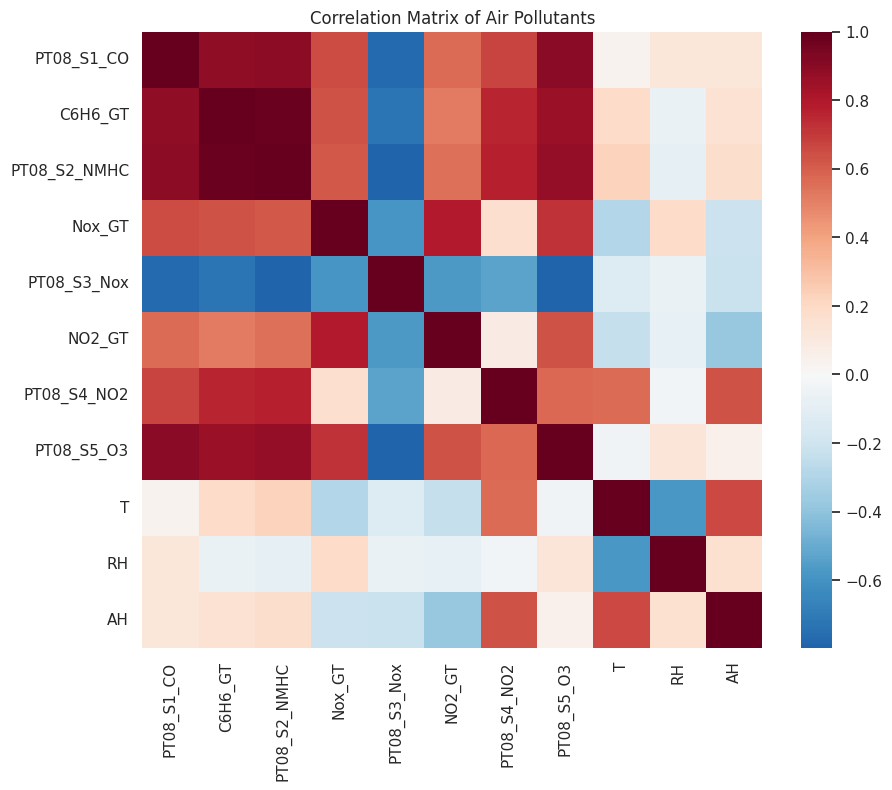

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=False, cmap='RdBu_r', center=0)
plt.title('Correlation Matrix of Air Pollutants')
plt.show()

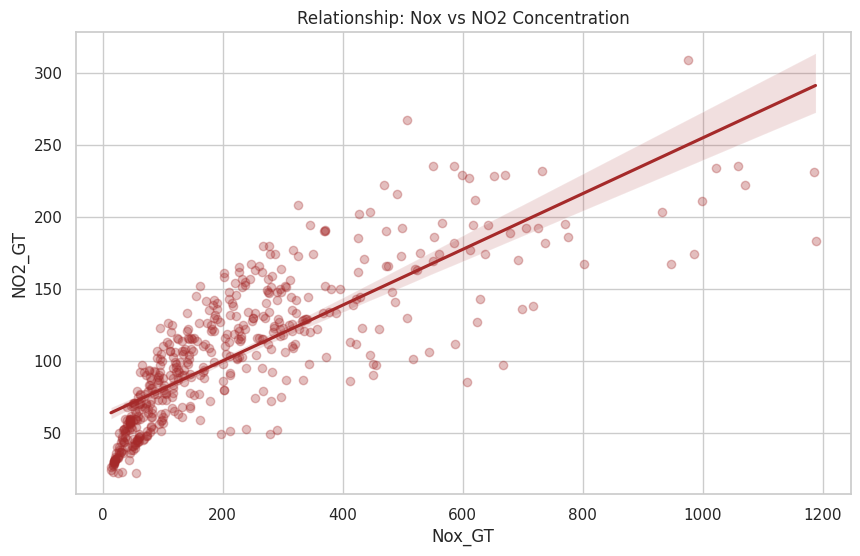

In [ ]:
plt.figure()
sns.regplot(x='Nox_GT', y='NO2_GT', data=df.sample(500), scatter_kws={'alpha':0.3}, color='brown')
plt.title('Relationship: Nox vs NO2 Concentration')
plt.show()

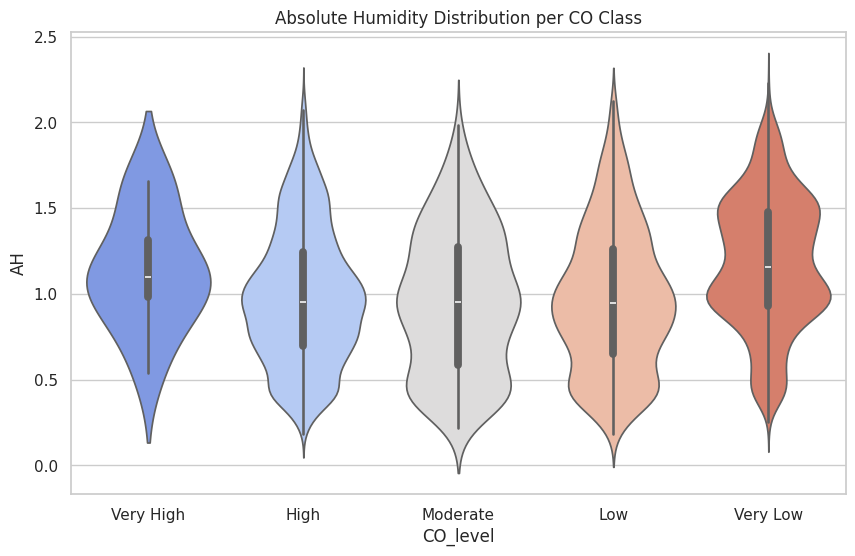

In [ ]:
plt.figure()
sns.violinplot(x='CO_level', y='AH', data=df, palette='coolwarm')
plt.title('Absolute Humidity Distribution per CO Class')
plt.show()

<Figure size 1000x600 with 0 Axes>

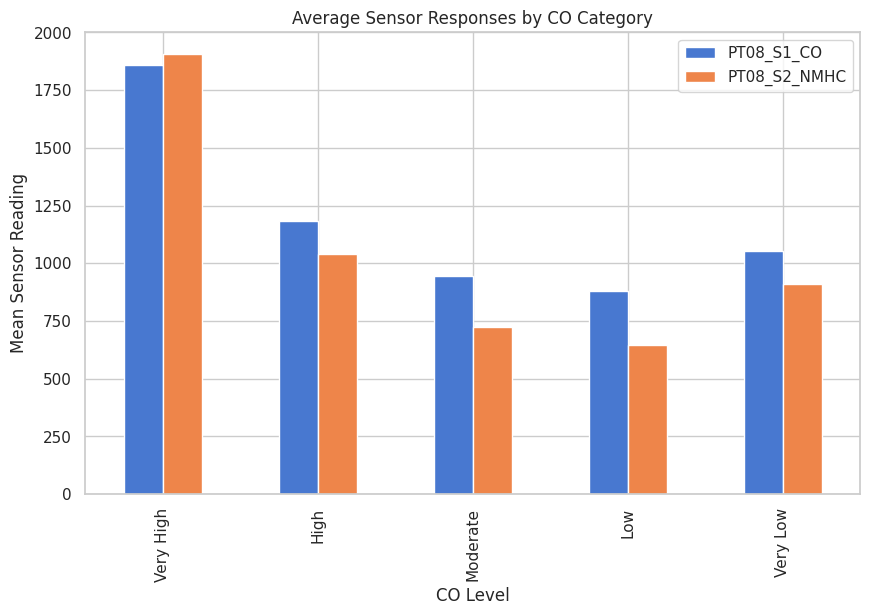

In [ ]:
plt.figure()

# Clean data
df['CO_level'] = df['CO_level'].str.strip().str.title()

# Define correct order (High → Low)
order = ['Very High', 'High', 'Moderate', 'Low', 'Very Low']

# Group and reorder
grouped = df.groupby('CO_level')[['PT08_S1_CO', 'PT08_S2_NMHC']].mean()
grouped = grouped.reindex(order)

# Plot
grouped.plot(kind='bar')

plt.title('Average Sensor Responses by CO Category')
plt.xlabel('CO Level')
plt.ylabel('Mean Sensor Reading')

plt.show()

In [ ]:
# -----------------------------------------------------------------------------
# STEP 3: PRE-PROCESSING & SPLITTING
# -----------------------------------------------------------------------------
# Encode the Target Variable
le = LabelEncoder()
df['CO_level'] = le.fit_transform(df['CO_level'].astype(str))

X = df.drop('CO_level', axis=1)
y = df['CO_level']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# -----------------------------------------------------------------------------
# STEP 4: MACHINE LEARNING MODELS
# -----------------------------------------------------------------------------
results = []

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, multi_class='ovr'),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

print("\nTraining 3 Machine Learning Models...")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    results.append({
        "Algorithm": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds, average='weighted'), 4),
        "Recall": round(recall_score(y_test, preds, average='weighted'), 4),
        "F1-Score": round(f1_score(y_test, preds, average='weighted'), 4)
    })


Training 3 Machine Learning Models...


In [ ]:
# -----------------------------------------------------------------------------
# STEP 5: FINAL PERFORMANCE RANK TABLE
# -----------------------------------------------------------------------------
rank_table = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
rank_table.index += 1
rank_table.index.name = "Rank"

print("\n" + "="*70)
print("MACHINE LEARNING PERFORMANCE RANK TABLE")
print("="*70)
print(rank_table)


MACHINE LEARNING PERFORMANCE RANK TABLE
                Algorithm  Accuracy  Precision  Recall  F1-Score
Rank                                                            
1           Random Forest    0.8611     0.8531  0.8611    0.8485
2           Decision Tree    0.8259     0.8118  0.8259    0.8164
3     Logistic Regression    0.8194     0.7945  0.8194    0.7963


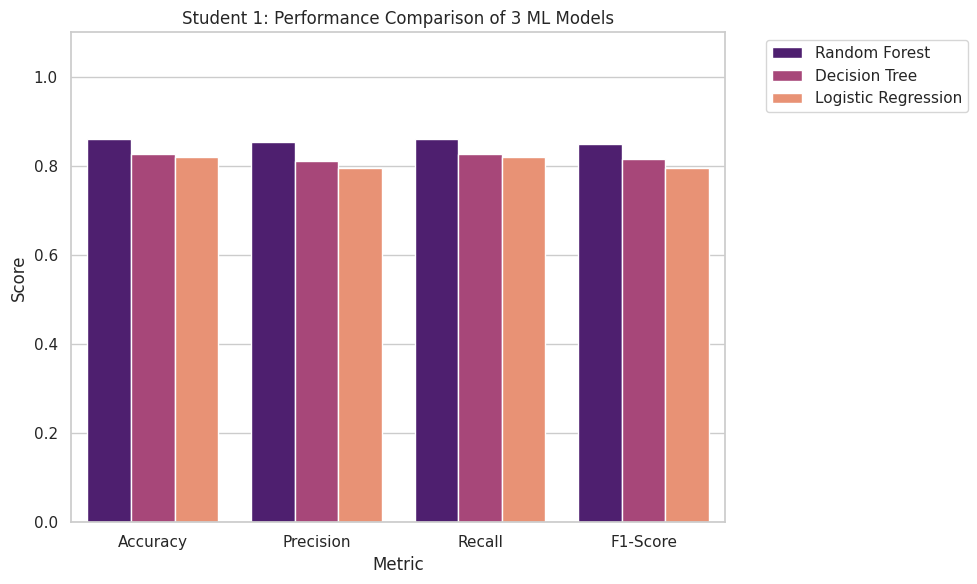

In [ ]:
# Performance Comparison Plot
plt.figure()
melted = rank_table.melt(id_vars='Algorithm', var_name='Metric', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Algorithm', data=melted, palette='magma')
plt.title('Student 1: Performance Comparison of 3 ML Models')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Random Forest Tuning Example
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

print("Starting Hyperparameter Tuning for Random Forest...")
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy')
grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_
print(f"Best Parameters: {grid_rf.best_params_}")

# K-Fold Cross Validation for the best model
cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Starting Hyperparameter Tuning for Random Forest...
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Mean CV Accuracy: 0.8660 (+/- 0.0160)


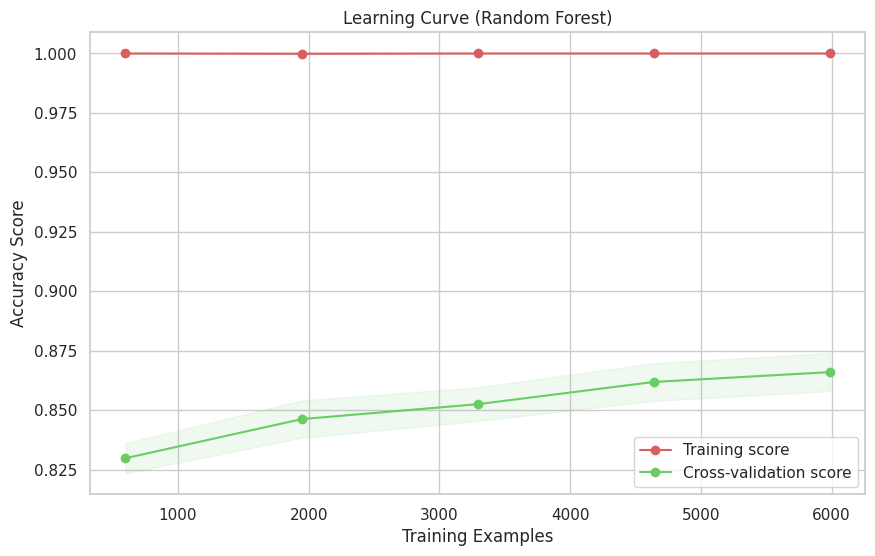


Final Test Set Accuracy: 0.8611111111111112


In [ ]:

# -----------------------------------------------------------------------------

def plot_learning_curve(estimator, title, X, y, cv=5):
    plt.figure(figsize=(10, 6))
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

    plt.title(title)
    plt.xlabel("Training Examples")
    plt.ylabel("Accuracy Score")
    plt.legend(loc="best")
    plt.show()

# Plotting for Random Forest
plot_learning_curve(best_rf, "Learning Curve (Random Forest)", X_train_scaled, y_train)

# Final Evaluation
y_pred = best_rf.predict(X_test_scaled)
print("\nFinal Test Set Accuracy:", accuracy_score(y_test, y_pred))